In [ ]:
# Dependency bootstrap for conda server kernel (run once if needed)
# !pip install -U wandb timm scikit-learn seaborn pandas matplotlib gradio kagglehub grad-cam
# !pip install --index-url https://download.pytorch.org/whl/cu128 torch torchvision torchaudio
# !pip install --force-reinstall "numpy<2" "opencv-python==4.8.1.78" --no-deps
# Optional (for FLOPs estimation):
# !pip install -U thop

In [ ]:
import os
import gc
import time
import shutil
import zipfile
import random
import warnings
import urllib.request
import sys
from dataclasses import dataclass, asdict
from pathlib import Path

import cv2
import timm
import torch
import wandb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
import PIL.ImageFile

# Truncated/corrupt JPEGs in some Kaggle zips otherwise raise OSError in DataLoader.
PIL.ImageFile.LOAD_TRUNCATED_IMAGES = True
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms

from pytorch_grad_cam import GradCAM, EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import gradio as gr

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Keep key in notebook as requested, but prefer environment variable when provided by server.
WANDB_DEFAULT_KEY = "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"
os.environ["WANDB_API_KEY"] = os.getenv("WANDB_API_KEY", WANDB_DEFAULT_KEY)

REQUIRE_CUDA = True
if REQUIRE_CUDA and DEVICE.type != "cuda":
    raise RuntimeError("CUDA is required for this notebook. Please switch to a CUDA-enabled conda kernel.")


Using device: cuda


In [17]:
@dataclass
class CFG:
    data_root: str = "./data/crop-pest-and-disease-detection"
    image_size: int = 224
    batch_size: int = 32
    # Windows + Jupyter: use 0 (multi-worker DataLoader often hangs). Linux server can try 4-8.
    num_workers: int = 0
    # thop FLOPs profiling runs BEFORE epoch 1 and can take many minutes; keep off unless needed.
    estimate_flops: bool = False
    epochs: int = 10
    # Dừng huấn luyện nếu val macro F1 không tăng trong N epoch liên tiếp; 0 = tắt early stopping.
    early_stopping_patience: int = 3
    # Giữ tỉ lệ trên mỗi lớp trước khi split train/val/test (1.0 = toàn bộ; 0.5 ≈ một nửa để chạy nhanh hơn).
    dataset_fraction: float = 0.5
    # Nếu đã có file .pt đúng tên run trong save_dir: bỏ qua train, chỉ eval test + lưu CM/CSV (để khớp results.csv).
    skip_training_if_checkpoint_exists: bool = True
    lr: float = 3e-4
    weight_decay: float = 1e-4
    val_ratio: float = 0.15
    test_ratio: float = 0.15
    project_name: str = "co3133-btl1-image"
    save_dir: str = "./artifacts_image"
    # False = skip the training loop below (EDA-only). True = run all experiments.
    run_experiments_now: bool = True

# Make paths stable regardless of notebook working directory.
project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
cfg = CFG(
    data_root=str(project_root / "data" / "crop-pest-and-disease-detection"),
    save_dir=str(project_root / "artifacts_image"),
)
Path(cfg.save_dir).mkdir(parents=True, exist_ok=True)
if sys.platform == "win32" and cfg.num_workers > 0:
    print("[cfg] Windows: forcing num_workers=0 to avoid DataLoader multiprocessing hangs in notebooks.")
    cfg.num_workers = 0
print(asdict(cfg))

{'data_root': 'C:\\Users\\haitr\\OneDrive\\Desktop\\DL-Assignment-DNAC1\\data\\crop-pest-and-disease-detection', 'image_size': 224, 'batch_size': 32, 'num_workers': 4, 'epochs': 10, 'lr': 0.0003, 'weight_decay': 0.0001, 'val_ratio': 0.15, 'test_ratio': 0.15, 'project_name': 'co3133-btl1-image', 'save_dir': 'C:\\Users\\haitr\\OneDrive\\Desktop\\DL-Assignment-DNAC1\\artifacts_image', 'run_experiments_now': False}


In [18]:
def ensure_crop_pest_dataset(cfg: CFG, source: str = "kaggle") -> str:
    """
    Ensure Crop Pest and Disease Detection exists at cfg.data_root.
    source: "kaggle" or "zip_url"
    - kaggle: download via kagglehub (dataset: nirmalsankalana/crop-pest-and-disease-detection)
    - zip_url: download from env var CROP_PEST_ZIP_URL
    """
    target = Path(cfg.data_root)
    if target.exists() and any(target.iterdir()):
        print(f"Dataset already exists: {target}")
        return str(target)

    target.parent.mkdir(parents=True, exist_ok=True)

    if source == "kaggle":
        import kagglehub

        ds_path = Path(kagglehub.dataset_download("nirmalsankalana/crop-pest-and-disease-detection"))
        print(f"Downloaded by kagglehub to: {ds_path}")

        candidate_dirs = [ds_path] + [p for p in ds_path.rglob("*") if p.is_dir()]
        selected = None
        for p in candidate_dirs:
            if not p.exists():
                continue
            class_dirs = [d for d in p.iterdir() if d.is_dir()]
            if len(class_dirs) >= 5:
                selected = p
                break

        if selected is None:
            raise RuntimeError("Cannot locate class folders after kaggle download. Please inspect downloaded path.")

        if target.exists():
            shutil.rmtree(target)
        shutil.copytree(selected, target)
        print(f"Prepared dataset at: {target}")
        return str(target)

    if source == "zip_url":
        zip_url = os.getenv("CROP_PEST_ZIP_URL", "").strip()
        if not zip_url:
            raise ValueError("CROP_PEST_ZIP_URL is empty. Please set environment variable first.")

        zip_path = target.parent / "crop_pest_dataset.zip"
        print(f"Downloading zip from: {zip_url}")
        urllib.request.urlretrieve(zip_url, zip_path)

        extract_dir = target.parent / "crop_pest_extracted"
        if extract_dir.exists():
            shutil.rmtree(extract_dir)
        extract_dir.mkdir(parents=True, exist_ok=True)

        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)

        candidate_dirs = [extract_dir] + [p for p in extract_dir.rglob("*") if p.is_dir()]
        selected = None
        for p in candidate_dirs:
            if not p.exists():
                continue
            class_dirs = [d for d in p.iterdir() if d.is_dir()]
            if len(class_dirs) >= 5:
                selected = p
                break

        if selected is None:
            raise RuntimeError("Cannot locate class folders in extracted zip.")

        if target.exists():
            shutil.rmtree(target)
        shutil.copytree(selected, target)
        print(f"Prepared dataset at: {target}")
        return str(target)

    raise ValueError("source must be 'kaggle' or 'zip_url'")


# Run this once on server before EDA/training.
# cfg.data_root = ensure_crop_pest_dataset(cfg, source="kaggle")
# Or: cfg.data_root = ensure_crop_pest_dataset(cfg, source="zip_url")

In [19]:
def discover_records(data_root: str, validate_images: bool = True) -> pd.DataFrame:
    root = Path(data_root)
    rows = []
    bad_files = []
    for class_dir in sorted([p for p in root.iterdir() if p.is_dir()]):
        for img_path in class_dir.glob("*.*"):
            if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
                continue
            if validate_images:
                try:
                    with Image.open(img_path) as im:
                        im.verify()
                except Exception:
                    bad_files.append(str(img_path))
                    continue
            rows.append({"path": str(img_path), "label": class_dir.name})

    if not rows:
        raise ValueError(f"No valid image found in: {data_root}")

    if bad_files:
        print(f"Skipped {len(bad_files)} corrupt/unreadable images.")
        print("First bad file:", bad_files[0])

    return pd.DataFrame(rows)

# Auto-download dataset if path is missing.
if not Path(cfg.data_root).exists():
    print(f"Dataset path not found: {cfg.data_root}")
    print("Downloading dataset via kagglehub...")
    cfg.data_root = ensure_crop_pest_dataset(cfg, source="kaggle")

df = discover_records(cfg.data_root, validate_images=True)
label2id = {c: i for i, c in enumerate(sorted(df["label"].unique()))}
id2label = {v: k for k, v in label2id.items()}
df["target"] = df["label"].map(label2id)
print("Dataset size (before optional subsample):", len(df), "| num classes:", len(label2id))

_frac = float(cfg.dataset_fraction)
if not (0.0 < _frac <= 1.0):
    raise ValueError("CFG.dataset_fraction must be in (0, 1]; use 1.0 for the full dataset.")
if _frac < 1.0:
    _before = len(df)

    def _strat_sample(g):
        n_take = max(1, min(len(g), int(np.ceil(len(g) * _frac))))
        return g.sample(n=n_take, random_state=SEED)

    df = df.groupby("target", group_keys=False).apply(_strat_sample).reset_index(drop=True)
    print(f"Stratified subsample: fraction={_frac} | rows {_before} -> {len(df)}")

train_df, holdout_df = train_test_split(df, test_size=cfg.val_ratio + cfg.test_ratio, random_state=SEED, stratify=df["target"])
relative_test = cfg.test_ratio / (cfg.val_ratio + cfg.test_ratio)
val_df, test_df = train_test_split(holdout_df, test_size=relative_test, random_state=SEED, stratify=holdout_df["target"])
print(f"Split sizes -> train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}")


Skipped 50 corrupt/unreadable images.
First bad file: C:\Users\haitr\OneDrive\Desktop\DL-Assignment-DNAC1\data\crop-pest-and-disease-detection\Maize healthy\healthy18_.jpg
Dataset size: 25170 | num classes: 22
Split sizes -> train: 17619 | val: 3775 | test: 3776


Unique classes: 22
Min/Max samples per class: 206 2743


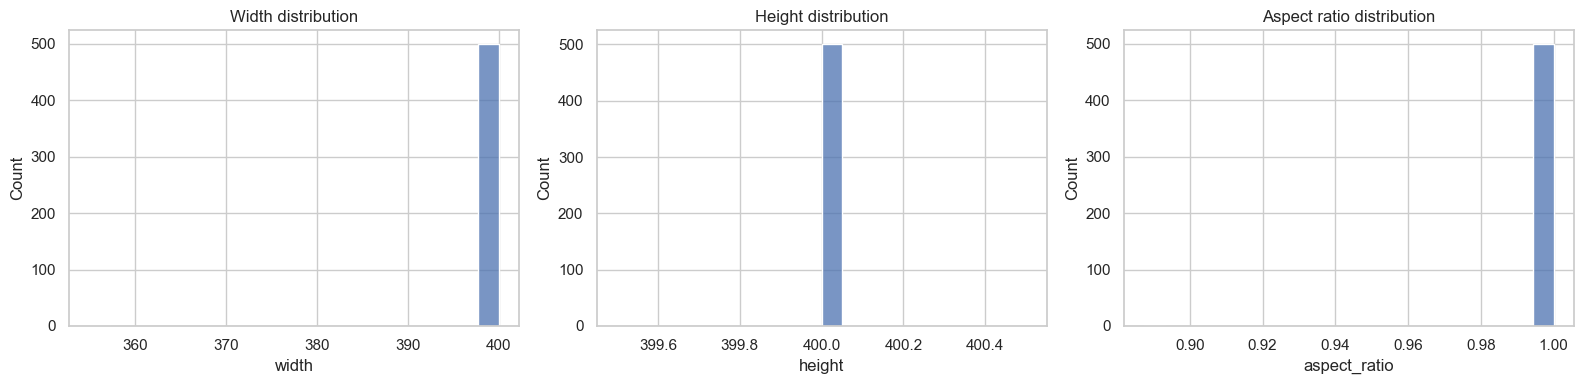

In [20]:
# Dataset sanity checks (inspired by stronger report-style pipelines)
print("Unique classes:", len(label2id))
print("Min/Max samples per class:", df["label"].value_counts().min(), df["label"].value_counts().max())

meta_rows = []
skipped_meta = 0
for p in df.sample(min(500, len(df)), random_state=SEED)["path"]:
    try:
        with Image.open(p) as im:
            w, h = im.size
        meta_rows.append((w, h, w / max(h, 1)))
    except Exception:
        skipped_meta += 1
        continue

if not meta_rows:
    raise ValueError("Cannot read sampled images for metadata analysis.")

if skipped_meta > 0:
    print(f"Skipped {skipped_meta} unreadable images in metadata sampling.")

meta_df = pd.DataFrame(meta_rows, columns=["width", "height", "aspect_ratio"])
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(meta_df["width"], bins=20, ax=axes[0]); axes[0].set_title("Width distribution")
sns.histplot(meta_df["height"], bins=20, ax=axes[1]); axes[1].set_title("Height distribution")
sns.histplot(meta_df["aspect_ratio"], bins=20, ax=axes[2]); axes[2].set_title("Aspect ratio distribution")
plt.tight_layout()

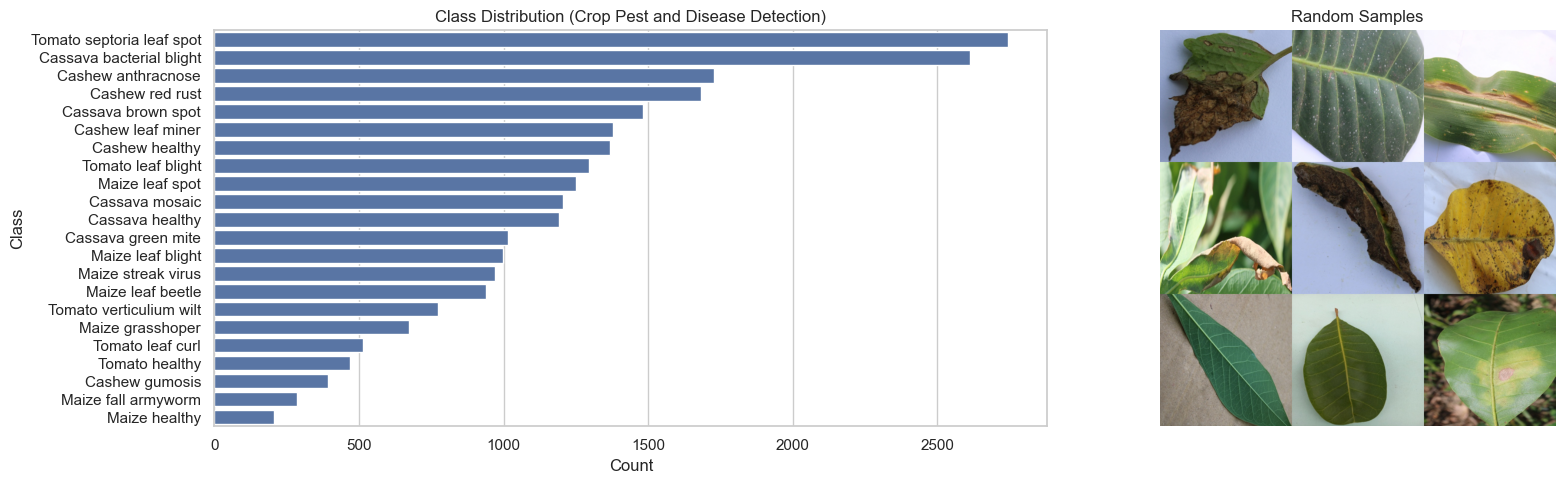

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.countplot(data=df, y="label", order=df["label"].value_counts().index, ax=axes[0])
axes[0].set_title("Class Distribution (Crop Pest and Disease Detection)")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Class")

sample_paths = df.sample(9, random_state=SEED)["path"].tolist()
grid = np.zeros((cfg.image_size * 3, cfg.image_size * 3, 3), dtype=np.uint8)
for i, p in enumerate(sample_paths):
    img = Image.open(p).convert("RGB").resize((cfg.image_size, cfg.image_size))
    r, c = divmod(i, 3)
    grid[r*cfg.image_size:(r+1)*cfg.image_size, c*cfg.image_size:(c+1)*cfg.image_size] = np.array(img)
axes[1].imshow(grid)
axes[1].axis("off")
axes[1].set_title("Random Samples")
plt.tight_layout()


In [22]:
def build_transforms(model_name: str, use_aug: bool, image_size: int):
    data_cfg = timm.data.resolve_model_data_config(timm.create_model(model_name, pretrained=False))
    mean, std = data_cfg["mean"], data_cfg["std"]
    if use_aug:
        train_tfms = transforms.Compose([
            transforms.RandomResizedCrop(image_size, scale=(0.7, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(p=0.1),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
            transforms.RandomRotation(20),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ])
    else:
        train_tfms = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ])
    eval_tfms = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])
    return train_tfms, eval_tfms

class ImageClassificationDataset(Dataset):
    """Loads images with retries for corrupt/truncated files common in large Kaggle sets."""

    def __init__(self, frame: pd.DataFrame, transform=None, open_retries: int = 20):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        self.open_retries = int(open_retries)

    def __len__(self):
        return len(self.frame)

    @staticmethod
    def _load_rgb(path: str) -> Image.Image:
        with Image.open(path) as im:
            return im.convert("RGB")

    def __getitem__(self, idx):
        if len(self.frame) == 0:
            raise ValueError("Empty dataframe")

        j = int(idx) % len(self.frame)
        last_err = None
        for _ in range(self.open_retries):
            row = self.frame.iloc[j]
            try:
                img = self._load_rgb(row.path)
                if self.transform is not None:
                    img = self.transform(img)
                return img, int(row.target), row.path
            except (OSError, IOError, ValueError) as e:
                last_err = e
                j = random.randrange(len(self.frame))

        raise OSError(f"Could not read image after {self.open_retries} tries (last idx={j}): {last_err}")


In [23]:
def denormalize_image(tensor_img: torch.Tensor, mean, std):
    mean = torch.tensor(mean, dtype=tensor_img.dtype).view(3, 1, 1)
    std = torch.tensor(std, dtype=tensor_img.dtype).view(3, 1, 1)
    x = tensor_img.cpu() * std + mean
    return torch.clamp(x, 0.0, 1.0)


def preview_augmentation_vs_noaug(model_name: str = "resnet18", n_samples: int = 4):
    train_aug, _ = build_transforms(model_name, use_aug=True, image_size=cfg.image_size)
    train_noaug, _ = build_transforms(model_name, use_aug=False, image_size=cfg.image_size)
    data_cfg = timm.data.resolve_model_data_config(timm.create_model(model_name, pretrained=False))
    mean, std = data_cfg["mean"], data_cfg["std"]

    sampled = train_df.sample(min(n_samples, len(train_df)), random_state=SEED)
    plt.figure(figsize=(10, 2.8 * len(sampled)))
    for i, row in enumerate(sampled.itertuples(index=False), start=1):
        pil = Image.open(row.path).convert("RGB")
        x_noaug = denormalize_image(train_noaug(pil), mean, std).permute(1, 2, 0).numpy()
        x_aug = denormalize_image(train_aug(pil), mean, std).permute(1, 2, 0).numpy()

        plt.subplot(len(sampled), 2, 2 * i - 1)
        plt.imshow(x_noaug)
        plt.title(f"No-Aug | {row.label}")
        plt.axis("off")

        plt.subplot(len(sampled), 2, 2 * i)
        plt.imshow(x_aug)
        plt.title(f"Aug | {row.label}")
        plt.axis("off")
    plt.tight_layout()

# Example:
# preview_augmentation_vs_noaug(model_name="resnet18", n_samples=6)

In [24]:
class ImageClassifier(nn.Module):
    def __init__(self, timm_name: str, n_classes: int, hidden_dim: int = 512):
        super().__init__()
        self.backbone = timm.create_model(timm_name, pretrained=True, num_classes=0)
        in_features = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x):
        return self.head(self.backbone(x))

def set_finetune_strategy(model: ImageClassifier, strategy: str):
    for p in model.backbone.parameters():
        p.requires_grad = strategy == "finetune_all"
    if strategy == "linear_probe":
        for n, p in model.backbone.named_parameters():
            p.requires_grad = n.startswith("blocks") or n.startswith("layer4")
    for p in model.head.parameters():
        p.requires_grad = True


In [ ]:
def estimate_flops_g(model: nn.Module, image_size: int) -> float:
    """Return FLOPs in G for one forward pass. NaN if thop is unavailable."""
    try:
        from thop import profile

        dummy = torch.randn(1, 3, image_size, image_size, device=DEVICE)
        model.eval()
        with torch.no_grad():
            flops, _ = profile(model, inputs=(dummy,), verbose=False)
        return float(flops) / 1e9
    except Exception:
        return float("nan")


def run_one_experiment(model_name: str, use_aug: bool, strategy: str, epochs: int = 10):
    train_tfms, eval_tfms = build_transforms(model_name, use_aug, cfg.image_size)
    train_ds = ImageClassificationDataset(train_df, train_tfms)
    val_ds = ImageClassificationDataset(val_df, eval_tfms)
    test_ds = ImageClassificationDataset(test_df, eval_tfms)

    _pin = DEVICE.type == "cuda"
    _pw = cfg.num_workers > 0
    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=_pin,
        persistent_workers=_pw,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=_pin,
        persistent_workers=_pw,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=_pin,
        persistent_workers=_pw,
    )

    run_name = f"{model_name}_{'aug' if use_aug else 'noaug'}_{strategy}"
    wandb.init(
        project=cfg.project_name,
        name=run_name,
        config={
            "model": model_name,
            "aug": use_aug,
            "strategy": strategy,
            "epochs": epochs,
            "early_stopping_patience": cfg.early_stopping_patience,
        },
    )

    model = ImageClassifier(model_name, len(label2id)).to(DEVICE)
    set_finetune_strategy(model, strategy)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda") if DEVICE.type == "cuda" else None

    num_params_m = sum(p.numel() for p in model.parameters()) / 1e6
    num_trainable_params_m = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
    if getattr(cfg, "estimate_flops", False):
        print(f"[train] {run_name} estimating FLOPs via thop (can take several minutes)...", flush=True)
        flops_g = estimate_flops_g(model, cfg.image_size)
    else:
        flops_g = float("nan")

    print(
        f"[train] {run_name} | train_batches={len(train_loader)} val_batches={len(val_loader)} "
        f"num_workers={cfg.num_workers} pin_memory={_pin}",
        flush=True,
    )

    best_f1 = -1.0
    best_path = str(Path(cfg.save_dir) / f"{run_name}.pt")
    skip_train = bool(getattr(cfg, "skip_training_if_checkpoint_exists", False)) and Path(best_path).is_file()

    if skip_train:
        print(f"[train] {run_name} SKIP training — dùng checkpoint có sẵn: {best_path}", flush=True)
        model.load_state_dict(torch.load(best_path, map_location=DEVICE))
        train_seconds = 0.0
        ep = 0
        stopped_early = False
        wandb.log({"skipped_training": True, "checkpoint_path": best_path})
    else:
        es_patience = max(0, int(cfg.early_stopping_patience))
        epochs_no_improve = 0
        stopped_early = False
        train_start = time.perf_counter()
        for ep in range(1, epochs + 1):
            print(f"[train] {run_name} epoch {ep}/{epochs} starting...", flush=True)
            ep_t0 = time.perf_counter()
            model.train()
            tr_losses, tr_preds, tr_targets = [], [], []
            for bi, (x, y, _) in enumerate(train_loader):
                if bi == 0:
                    print(f"[train] {run_name} epoch {ep}: first training batch after {time.perf_counter() - ep_t0:.2f}s", flush=True)
                x, y = x.to(DEVICE), y.to(DEVICE)
                optimizer.zero_grad(set_to_none=True)
                if scaler is not None:
                    with torch.autocast(device_type="cuda", dtype=torch.float16):
                        logits = model(x)
                        loss = criterion(logits, y)
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    logits = model(x)
                    loss = criterion(logits, y)
                    loss.backward()
                    optimizer.step()
                tr_losses.append(loss.item())
                tr_preds.extend(logits.argmax(1).detach().cpu().numpy())
                tr_targets.extend(y.detach().cpu().numpy())

            model.eval()
            va_losses, va_preds, va_targets = [], [], []
            with torch.no_grad():
                for x, y, _ in val_loader:
                    x, y = x.to(DEVICE), y.to(DEVICE)
                    logits = model(x)
                    loss = criterion(logits, y)
                    va_losses.append(loss.item())
                    va_preds.extend(logits.argmax(1).cpu().numpy())
                    va_targets.extend(y.cpu().numpy())

            tr_acc = accuracy_score(tr_targets, tr_preds)
            va_acc = accuracy_score(va_targets, va_preds)
            va_f1 = f1_score(va_targets, va_preds, average="macro")
            wandb.log({
                "epoch": ep,
                "train_loss": float(np.mean(tr_losses)),
                "val_loss": float(np.mean(va_losses)),
                "train_acc": tr_acc,
                "val_acc": va_acc,
                "val_f1": va_f1,
                "lr": optimizer.param_groups[0]["lr"],
            })
            improved = va_f1 > best_f1
            if improved:
                best_f1 = va_f1
                torch.save(model.state_dict(), best_path)
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
            scheduler.step()

            if es_patience > 0 and epochs_no_improve >= es_patience:
                print(
                    f"[train] {run_name} early stopping at epoch {ep}/{epochs} "
                    f"(val macro F1 did not improve for {es_patience} epoch(s); best val_f1={best_f1:.4f})",
                    flush=True,
                )
                wandb.log({"early_stopped": True, "early_stop_epoch": ep})
                stopped_early = True
                break

        train_seconds = time.perf_counter() - train_start
        model.load_state_dict(torch.load(best_path, map_location=DEVICE))

    model.eval()

    te_preds, te_targets, te_paths = [], [], []
    te_conf, te_true_prob = [], []
    infer_start = time.perf_counter()
    with torch.no_grad():
        for x, y, paths in test_loader:
            logits = model(x.to(DEVICE))
            probs = torch.softmax(logits, dim=1)
            pred = probs.argmax(1)

            te_preds.extend(pred.cpu().numpy())
            te_targets.extend(y.numpy())
            te_paths.extend(paths)
            te_conf.extend(probs.max(1).values.cpu().numpy())
            te_true_prob.extend(probs[torch.arange(probs.size(0), device=probs.device), y.to(DEVICE)].cpu().numpy())

    infer_seconds = time.perf_counter() - infer_start
    infer_ms_per_image = (infer_seconds / max(len(test_ds), 1)) * 1000.0

    labels_order = list(range(len(id2label)))
    class_names = [id2label[i] for i in labels_order]

    cm = confusion_matrix(te_targets, te_preds, labels=labels_order)
    cm_path = Path(cfg.save_dir) / f"cm_{run_name}.png"
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {run_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(cm_path, dpi=160)
    plt.close()

    cm_norm = cm.astype(np.float64) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
    cm_norm_path = Path(cfg.save_dir) / f"cm_norm_{run_name}.png"
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm * 100.0, cmap="Blues", fmt=".1f", annot=False, xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Normalized Confusion Matrix (%) - {run_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(cm_norm_path, dpi=160)
    plt.close()

    pred_df = pd.DataFrame(
        {
            "path": te_paths,
            "target": te_targets,
            "pred": te_preds,
            "pred_confidence": te_conf,
            "true_class_probability": te_true_prob,
        }
    )
    pred_df["target_name"] = pred_df["target"].map(id2label)
    pred_df["pred_name"] = pred_df["pred"].map(id2label)

    mis_df = pred_df[pred_df["target"] != pred_df["pred"]].copy()
    mis_path = Path(cfg.save_dir) / f"misclassified_{run_name}.csv"
    mis_df.to_csv(mis_path, index=False)

    top_conf_wrong = mis_df.sort_values("pred_confidence", ascending=False).head(100).copy()
    top_conf_wrong_path = Path(cfg.save_dir) / f"top_confident_wrong_{run_name}.csv"
    top_conf_wrong.to_csv(top_conf_wrong_path, index=False)

    ckpt_size_mb = Path(best_path).stat().st_size / (1024 ** 2) if Path(best_path).exists() else float("nan")

    result = {
        "run_name": run_name,
        "model": model_name,
        "augmentation": "aug" if use_aug else "noaug",
        "finetune": strategy,
        "accuracy": accuracy_score(te_targets, te_preds),
        "precision": precision_score(te_targets, te_preds, average="macro", zero_division=0),
        "recall": recall_score(te_targets, te_preds, average="macro", zero_division=0),
        "f1": f1_score(te_targets, te_preds, average="macro"),
        "params_m": num_params_m,
        "trainable_params_m": num_trainable_params_m,
        "flops_g": flops_g,
        "ckpt_size_mb": ckpt_size_mb,
        "train_time_sec": train_seconds,
        "epochs_trained": ep,
        "early_stopped": stopped_early,
        "infer_ms_per_image": infer_ms_per_image,
        "confusion_matrix_path": str(cm_path),
        "confusion_matrix_norm_path": str(cm_norm_path),
        "misclassified_path": str(mis_path),
        "top_confident_wrong_path": str(top_conf_wrong_path),
        "ckpt": best_path,
        "wandb_url": wandb.run.url,
    }

    wandb.log({
        "test_confusion_matrix": wandb.Image(str(cm_path)),
        "test_confusion_matrix_normalized": wandb.Image(str(cm_norm_path)),
    })
    if len(mis_df) > 0:
        wandb.log({"misclassified_table": wandb.Table(dataframe=mis_df.head(200))})
    if len(top_conf_wrong) > 0:
        wandb.log({"top_confident_wrong_table": wandb.Table(dataframe=top_conf_wrong)})

    wandb.summary.update(result)
    wandb.finish()

    del model
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return result


In [26]:
# 8 thí nghiệm — đa dạng; 2 dòng đầu khớp checkpoint bạn đã train (resnet18_aug_frozen / resnet18_aug_linear_probe).
# Nếu cfg.skip_training_if_checkpoint_exists=True và đã có .pt trong save_dir → bỏ qua train, chỉ eval test.
# Dữ liệu: cfg.dataset_fraction (mặc định 0.5) subsample stratified trước khi split.
EXPERIMENT_PLAN = [
    ("resnet18", True, "frozen"),
    ("resnet18", True, "linear_probe"),
    ("resnet18", False, "finetune_all"),
    ("efficientnet_b0", True, "finetune_all"),
    ("efficientnet_b0", False, "frozen"),
    ("vit_base_patch16_224", True, "linear_probe"),
    ("vit_base_patch16_224", False, "finetune_all"),
    ("swin_tiny_patch4_window7_224", True, "frozen"),
]

results = []
if cfg.run_experiments_now:
    for model_name, aug, ft in EXPERIMENT_PLAN:
        results.append(run_one_experiment(model_name, aug, ft, epochs=cfg.epochs))
    pd.DataFrame(results).to_csv(Path(cfg.save_dir) / "results.csv", index=False)
else:
    print("=" * 60)
    print("[SKIP] Không chạy training: cfg.run_experiments_now = False")
    print("Đặt: cfg.run_experiments_now = True rồi chạy lại cell này.")
    print("=" * 60)


Set cfg.run_experiments_now=True when running on server/GPU.


In [ ]:
results_csv = Path(cfg.save_dir) / "results.csv"
if results_csv.exists():
    df_res = pd.read_csv(results_csv)

    preferred_cols = [
        "run_name", "model", "augmentation", "finetune", "accuracy", "precision", "recall", "f1",
        "params_m", "trainable_params_m", "flops_g", "ckpt_size_mb", "train_time_sec", "infer_ms_per_image",
        "confusion_matrix_path", "confusion_matrix_norm_path", "top_confident_wrong_path", "wandb_url"
    ]
    ranking_cols = [c for c in preferred_cols if c in df_res.columns]
    df_rank = df_res[ranking_cols].sort_values(["f1", "accuracy"], ascending=False).reset_index(drop=True)
    display(df_rank)

    # Compare Aug vs No-Aug directly.
    df_aug = df_res[df_res["augmentation"] == "aug"].sort_values(["f1", "accuracy"], ascending=False).reset_index(drop=True)
    df_noaug = df_res[df_res["augmentation"] == "noaug"].sort_values(["f1", "accuracy"], ascending=False).reset_index(drop=True)
    print("Top runs (Aug):")
    display(df_aug.head(10))
    print("Top runs (No-Aug):")
    display(df_noaug.head(10))

    # Top-1 / Top-2 by each metric.
    metric_cols = [c for c in ["accuracy", "precision", "recall", "f1"] if c in df_res.columns]
    top_rows = []
    for metric in metric_cols:
        top2 = df_res.sort_values(metric, ascending=False).head(2).reset_index(drop=True)
        for i, row in top2.iterrows():
            top_rows.append({
                "metric": metric,
                "rank": i + 1,
                "run_name": row["run_name"],
                "model": row["model"],
                "augmentation": row["augmentation"],
                "finetune": row["finetune"],
                "value": row[metric],
            })
    top_metric_df = pd.DataFrame(top_rows)
    display(top_metric_df)

    pivot_aug = df_res.pivot_table(index=["model", "finetune"], columns="augmentation", values=["accuracy", "f1", "precision", "recall"])
    display(pivot_aug)

    # Export for landing page/report artifacts.
    df_rank.to_csv(Path(cfg.save_dir) / "leaderboard.csv", index=False)
    df_aug.to_csv(Path(cfg.save_dir) / "leaderboard_aug.csv", index=False)
    df_noaug.to_csv(Path(cfg.save_dir) / "leaderboard_noaug.csv", index=False)
    top_metric_df.to_csv(Path(cfg.save_dir) / "top_by_metric.csv", index=False)
    df_res.groupby("model")[["accuracy", "f1", "train_time_sec", "infer_ms_per_image"]].mean().reset_index().to_csv(Path(cfg.save_dir) / "metrics_by_model.csv", index=False)
    df_res.groupby("finetune")[["accuracy", "f1", "train_time_sec", "infer_ms_per_image"]].mean().reset_index().to_csv(Path(cfg.save_dir) / "metrics_by_finetune.csv", index=False)
    df_res.groupby("augmentation")[["accuracy", "f1", "train_time_sec", "infer_ms_per_image"]].mean().reset_index().to_csv(Path(cfg.save_dir) / "metrics_by_augmentation.csv", index=False)

    plt.figure(figsize=(12, 5))
    sns.barplot(data=df_res, x="model", y="f1", hue="augmentation")
    plt.xticks(rotation=15)
    plt.title("Macro F1: Backbone x Aug/No-Aug")
    plt.tight_layout()

    plt.figure(figsize=(12, 5))
    sns.barplot(data=df_res, x="model", y="accuracy", hue="finetune")
    plt.xticks(rotation=15)
    plt.title("Accuracy: Backbone x Finetune Strategy")
    plt.tight_layout()

    plt.figure(figsize=(12, 5))
    sns.barplot(data=df_res, x="model", y="infer_ms_per_image", hue="finetune")
    plt.xticks(rotation=15)
    plt.title("Efficiency: Inference ms/image")
    plt.tight_layout()
else:
    print("No results.csv found yet.")


No results.csv found yet.


In [28]:
def benchmark_inference_from_run(results_path: str, run_name: str, warmup: int = 20, repeat: int = 100):
    df_res = pd.read_csv(results_path)
    row = df_res[df_res["run_name"] == run_name].iloc[0].to_dict()

    model = ImageClassifier(row["model"], n_classes=len(label2id)).to(DEVICE)
    model.load_state_dict(torch.load(row["ckpt"], map_location=DEVICE))
    model.eval()

    _, eval_tfms = build_transforms(row["model"], use_aug=False, image_size=cfg.image_size)
    sample_path = test_df.sample(1, random_state=SEED)["path"].iloc[0]
    x = eval_tfms(Image.open(sample_path).convert("RGB")).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(x)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        t0 = time.perf_counter()
        for _ in range(repeat):
            _ = model(x)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()

    latency_ms = ((t1 - t0) / repeat) * 1000.0
    fps = 1000.0 / max(latency_ms, 1e-9)
    print(f"Run: {run_name}")
    print(f"Latency (1 image): {latency_ms:.3f} ms")
    print(f"Throughput (batch=1): {fps:.2f} FPS")

# Example:
# benchmark_inference_from_run("./artifacts_image/results.csv", "resnet18_aug_finetune_all")

In [29]:
def select_target_layer(model: ImageClassifier, model_name: str):
    if "resnet" in model_name:
        return [model.backbone.layer4[-1]]
    if "efficientnet" in model_name:
        return [model.backbone.conv_head]
    if "vit" in model_name and hasattr(model.backbone, "blocks"):
        return [model.backbone.blocks[-1].norm1]
    if "swin" in model_name and hasattr(model.backbone, "layers"):
        return [model.backbone.layers[-1].blocks[-1].norm1]
    raise ValueError(f"Unsupported model: {model_name}")

def cam_visualize(model_name: str, ckpt_path: str, image_path: str, use_eigen: bool = False):
    model = ImageClassifier(model_name, n_classes=len(label2id)).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    _, eval_tfms = build_transforms(model_name, use_aug=False, image_size=cfg.image_size)
    raw = np.array(Image.open(image_path).convert("RGB").resize((cfg.image_size, cfg.image_size)))
    x = eval_tfms(Image.fromarray(raw)).unsqueeze(0).to(DEVICE)
    target_layers = select_target_layer(model, model_name)
    cam_cls = EigenCAM if use_eigen else GradCAM
    cam = cam_cls(model=model, target_layers=target_layers)
    grayscale_cam = cam(input_tensor=x)[0]
    overlay = show_cam_on_image(raw.astype(np.float32) / 255.0, grayscale_cam, use_rgb=True)
    return raw, overlay

# Example:
# raw, cam = cam_visualize("resnet18", "./artifacts_image/resnet18_aug_finetune_all.pt", "/path/to/hard_sample.jpg", use_eigen=False)


In [ ]:
def load_best_for_demo(results_path: str):
    df_res = pd.read_csv(results_path).sort_values("f1", ascending=False).reset_index(drop=True)
    best = df_res.iloc[0].to_dict()
    model = ImageClassifier(best["model"], n_classes=len(label2id)).to(DEVICE)
    model.load_state_dict(torch.load(best["ckpt"], map_location=DEVICE))
    model.eval()
    _, tfm = build_transforms(best["model"], use_aug=False, image_size=cfg.image_size)
    return model, tfm, best


def build_gradio_app(results_path: str):
    model, tfm, best = load_best_for_demo(results_path)

    def predict(image):
        x = tfm(image.convert("RGB")).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            prob = torch.softmax(model(x), dim=1)[0].cpu().numpy()
        return {id2label[i]: float(prob[i]) for i in range(len(id2label))}

    return gr.Interface(
        fn=predict,
        inputs=gr.Image(type="pil"),
        outputs=gr.Label(num_top_classes=5),
        title=f"Crop Pest & Disease Demo | {best['run_name']}",
        description=f"WandB run: {best['wandb_url']}",
    )


def export_hf_space_files(results_path: str, out_dir: str = "./notebooks/hf_space_image_demo"):
    """Create minimal Hugging Face Space files for deploying the Gradio demo."""
    out_path = Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    req_text = "\n".join([
        "torch",
        "torchvision",
        "timm",
        "gradio",
        "pandas",
        "numpy",
        "pillow",
    ])
    (out_path / "requirements.txt").write_text(req_text, encoding="utf-8")

    app_py = '''import os
import json
from pathlib import Path

import gradio as gr
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import timm
from PIL import Image
import PIL.ImageFile
PIL.ImageFile.LOAD_TRUNCATED_IMAGES = True
from torchvision import transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RESULTS_PATH = Path("./results.csv")
if not RESULTS_PATH.exists():
    raise FileNotFoundError("results.csv not found in Space root.")

DF = pd.read_csv(RESULTS_PATH).sort_values("f1", ascending=False).reset_index(drop=True)
BEST = DF.iloc[0].to_dict()

LABELS_PATH = Path("./labels.json")
if not LABELS_PATH.exists():
    raise FileNotFoundError("labels.json not found in Space root.")
ID2LABEL = {int(k): v for k, v in json.loads(LABELS_PATH.read_text(encoding="utf-8")).items()}

class ImageClassifier(nn.Module):
    def __init__(self, timm_name: str, n_classes: int, hidden_dim: int = 512):
        super().__init__()
        self.backbone = timm.create_model(timm_name, pretrained=False, num_classes=0)
        in_features = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x):
        return self.head(self.backbone(x))


def build_tfm(image_size: int = 224):
    data_cfg = timm.data.resolve_model_data_config(timm.create_model(BEST["model"], pretrained=False))
    mean, std = data_cfg["mean"], data_cfg["std"]
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])


MODEL = ImageClassifier(BEST["model"], n_classes=len(ID2LABEL)).to(DEVICE)
MODEL.load_state_dict(torch.load(BEST["ckpt"], map_location=DEVICE))
MODEL.eval()
TFM = build_tfm()


def predict(image):
    x = TFM(image.convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        prob = torch.softmax(MODEL(x), dim=1)[0].cpu().numpy()
    return {ID2LABEL[i]: float(prob[i]) for i in range(len(ID2LABEL))}


app = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=5),
    title=f"Crop Pest & Disease Demo | {BEST['run_name']}",
    description=f"WandB run: {BEST['wandb_url']}",
)

if __name__ == "__main__":
    app.launch()
'''
    (out_path / "app.py").write_text(app_py, encoding="utf-8")

    labels_json = {str(k): v for k, v in id2label.items()}
    (out_path / "labels.json").write_text(pd.Series(labels_json).to_json(force_ascii=False), encoding="utf-8")

    df_res = pd.read_csv(results_path)
    df_res.to_csv(out_path / "results.csv", index=False)

    print(f"Exported HF Space files to: {out_path}")
    print("Next: copy checkpoint files referenced in results.csv into the same folder before pushing to Space.")


# app = build_gradio_app("./artifacts_image/results.csv")
# app.launch(share=False)
# export_hf_space_files("./artifacts_image/results.csv")


In [31]:
def visualize_hard_samples_from_run(results_path: str, run_name: str, k: int = 4):
    df_res = pd.read_csv(results_path)
    row = df_res[df_res["run_name"] == run_name].iloc[0].to_dict()
    mis_df = pd.read_csv(row["misclassified_path"])
    if len(mis_df) == 0:
        print("No misclassified samples for this run.")
        return

    subset = mis_df.sample(min(k, len(mis_df)), random_state=SEED)
    is_transformer = ("vit" in row["model"]) or ("swin" in row["model"])

    plt.figure(figsize=(12, 3 * len(subset)))
    for i, r in enumerate(subset.itertuples(index=False), start=1):
        raw, cam = cam_visualize(
            model_name=row["model"],
            ckpt_path=row["ckpt"],
            image_path=r.path,
            use_eigen=is_transformer,
        )
        plt.subplot(len(subset), 2, 2 * i - 1)
        plt.imshow(raw)
        plt.title(f"Raw | True: {r.target_name}")
        plt.axis("off")

        plt.subplot(len(subset), 2, 2 * i)
        plt.imshow(cam)
        plt.title(f"{'EigenCAM' if is_transformer else 'GradCAM'} | Pred: {r.pred_name}")
        plt.axis("off")
    plt.tight_layout()

# Example:
# visualize_hard_samples_from_run("./artifacts_image/results.csv", "resnet18_aug_finetune_all", k=6)

In [32]:
def visualize_top_confident_errors(results_path: str, run_name: str, k: int = 6):
    df_res = pd.read_csv(results_path)
    row = df_res[df_res["run_name"] == run_name].iloc[0].to_dict()

    err_path = row.get("top_confident_wrong_path", "")
    if not err_path:
        print("This run does not contain top_confident_wrong_path.")
        return

    err_df = pd.read_csv(err_path)
    if len(err_df) == 0:
        print("No wrong predictions for this run.")
        return

    top_df = err_df.sort_values("pred_confidence", ascending=False).head(k)
    is_transformer = ("vit" in row["model"]) or ("swin" in row["model"])

    plt.figure(figsize=(13, 3.2 * len(top_df)))
    for i, r in enumerate(top_df.itertuples(index=False), start=1):
        raw, cam = cam_visualize(
            model_name=row["model"],
            ckpt_path=row["ckpt"],
            image_path=r.path,
            use_eigen=is_transformer,
        )

        plt.subplot(len(top_df), 2, 2 * i - 1)
        plt.imshow(raw)
        plt.title(f"True={r.target_name} | Pred={r.pred_name}")
        plt.axis("off")

        plt.subplot(len(top_df), 2, 2 * i)
        plt.imshow(cam)
        plt.title(f"CAM | conf={r.pred_confidence:.3f} | p_true={r.true_class_probability:.3f}")
        plt.axis("off")

    plt.tight_layout()

# Example:
# visualize_top_confident_errors("./artifacts_image/results.csv", "resnet18_aug_finetune_all", k=6)